# The PageRank Algorithm

**Source:** https://labs.acme.byu.edu/Volume1/PageRank/PageRank.html

PageRank models a random web surfer who follows links uniformly at random (with occasional teleportation to any page). The stationary distribution of this Markov chain gives each page a **rank** proportional to how likely the surfer is to visit it. This lab implements PageRank via iterative power method and eigenvector computation.

In [1]:
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from scipy import linalg as la

## 1. The PageRank Model

Given a directed graph with $n$ nodes, build adjacency matrix $A$ where $A_{ij} = 1$ if page $j$ links to page $i$. Normalize columns to get the **column-stochastic** transition matrix $K$.

The **Google matrix** adds teleportation:
$$\hat{K} = d\,K + \frac{1-d}{n}\mathbf{1}\mathbf{1}^T$$

where $d \approx 0.85$ is the **damping factor**. PageRank is the dominant eigenvector of $\hat{K}$.

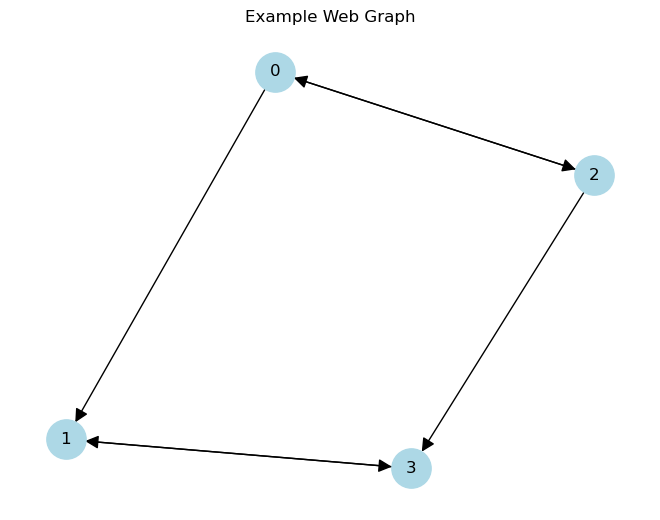

In [2]:
# Tiny example: 4-page web graph
# Edges: 1→2, 1→3, 2→4, 3→1, 3→4, 4→2
G_small = nx.DiGraph()
G_small.add_edges_from([(0,1),(0,2),(1,3),(2,0),(2,3),(3,1)])


pos = nx.spring_layout(G_small, seed=1)
nx.draw(G_small, pos, with_labels=True, node_color='lightblue',
        arrows=True, arrowsize=20, node_size=800)
plt.title('Example Web Graph')
plt.show()

---

## Problem 1: Build the Transition Matrix

Given a directed graph (as an adjacency matrix), return the column-stochastic transition matrix K. Handle dangling nodes (nodes with no out-links) by distributing their probability uniformly.

In [3]:
def prob1(A):
    """Build the column-stochastic transition matrix from adjacency matrix A.
    
    Parameters
    ----------
    A : ndarray (n, n), A[i,j]=1 if j→i
    
    Returns
    -------
    K : ndarray (n, n), column-stochastic
    """
    n = A.shape[0]
    K = A.astype(float).copy()
    col_sums = K.sum(axis=0)
    
    # Dangling nodes: distribute probability uniformly
    dangling = col_sums == 0
    K[:, dangling] = 1.0 / n
    # Normalize non-dangling columns
    non_dangling = ~dangling
    K[:, non_dangling] /= col_sums[non_dangling]
    return K


# Build adjacency matrix from small graph (A[i,j]=1 if j→i)
n = G_small.number_of_nodes()
A = np.zeros((n, n))
for src, dst in G_small.edges():
    A[dst, src] = 1   # j→i means A[i,j]=1

K = prob1(A)
print("Transition matrix K:")
print(np.round(K, 3))
print("Column sums (should all be 1):", K.sum(axis=0))

Transition matrix K:
[[0.  0.  0.5 0. ]
 [0.5 0.  0.  1. ]
 [0.5 0.  0.  0. ]
 [0.  1.  0.5 0. ]]
Column sums (should all be 1): [1. 1. 1. 1.]


## Problem 2: PageRank via Eigenvalue

Build the Google matrix $\hat{K}$ and compute PageRank as the dominant eigenvector (normalized to sum to 1).

In [4]:
def prob2(A, d=0.85):
    """PageRank via dominant eigenvector of the Google matrix.
    
    Parameters
    ----------
    A : adjacency matrix (n, n)
    d : damping factor (default 0.85)
    
    Returns
    -------
    ranks : ndarray (n,), summing to 1
    """
    n = A.shape[0]
    K = prob1(A)
    K_hat = d * K + (1 - d) / n * np.ones((n, n))
    
    eigenvalues, eigenvectors = la.eig(K_hat)
    # Dominant eigenvector (eigenvalue ≈ 1)
    idx = np.argmax(eigenvalues.real)
    ranks = eigenvectors[:, idx].real
    ranks = np.abs(ranks)
    ranks /= ranks.sum()
    return ranks


ranks = prob2(A)
print("PageRank scores:")
for i, r in enumerate(ranks):
    print(f"  Page {i}: {r:.4f}")

# Compare with NetworkX

nx_ranks = nx.pagerank(G_small, alpha=0.85)
print("\nNetworkX PageRank:")
for i, r in nx_ranks.items():
    print(f"  Page {i}: {r:.4f}")

PageRank scores:
  Page 0: 0.0652
  Page 1: 0.4348
  Page 2: 0.0652
  Page 3: 0.4348

NetworkX PageRank:
  Page 0: 0.0652
  Page 1: 0.4348
  Page 2: 0.0652
  Page 3: 0.4348


## Problem 3: PageRank via Power Method

Iteratively multiply: $\mathbf{p}^{(k+1)} = \hat{K}\,\mathbf{p}^{(k)}$ until convergence. More efficient for large sparse graphs.

In [5]:
def prob3(A, d=0.85, tol=1e-10, max_iter=1000):
    """PageRank via power method iteration."""
    n = A.shape[0]
    K = prob1(A)
    p = np.ones(n) / n   # uniform initial distribution
    
    for i in range(max_iter):
        p_new = d * K @ p + (1 - d) / n * np.ones(n)
        if np.linalg.norm(p_new - p) < tol:
            print(f"Converged in {i+1} iterations")
            break
        p = p_new
        
    
    return p_new / p_new.sum()


ranks_power = prob3(A)
print("\nPower Method PageRank:")
for i, r in enumerate(ranks_power):
    print(f"  Page {i}: {r:.4f}")

print("\nMax diff vs eigenvector method:", np.max(np.abs(ranks_power - ranks)))

Converged in 27 iterations

Power Method PageRank:
  Page 0: 0.0652
  Page 1: 0.4348
  Page 2: 0.0652
  Page 3: 0.4348

Max diff vs eigenvector method: 1.7106635552543992e-11


## Problem 4: Effect of Damping Factor

How do PageRank scores change as d varies from 0 (pure teleportation) to 1 (pure link-following)?

Converged in 1 iterations
Converged in 5 iterations
Converged in 6 iterations
Converged in 7 iterations
Converged in 7 iterations
Converged in 8 iterations
Converged in 8 iterations
Converged in 9 iterations
Converged in 9 iterations
Converged in 10 iterations
Converged in 10 iterations
Converged in 11 iterations
Converged in 11 iterations
Converged in 12 iterations
Converged in 12 iterations
Converged in 12 iterations
Converged in 13 iterations
Converged in 13 iterations
Converged in 14 iterations
Converged in 14 iterations
Converged in 14 iterations
Converged in 15 iterations
Converged in 15 iterations
Converged in 16 iterations
Converged in 16 iterations
Converged in 17 iterations
Converged in 17 iterations
Converged in 18 iterations
Converged in 18 iterations
Converged in 19 iterations
Converged in 19 iterations
Converged in 20 iterations
Converged in 20 iterations
Converged in 21 iterations
Converged in 21 iterations
Converged in 22 iterations
Converged in 23 iterations
Converged 

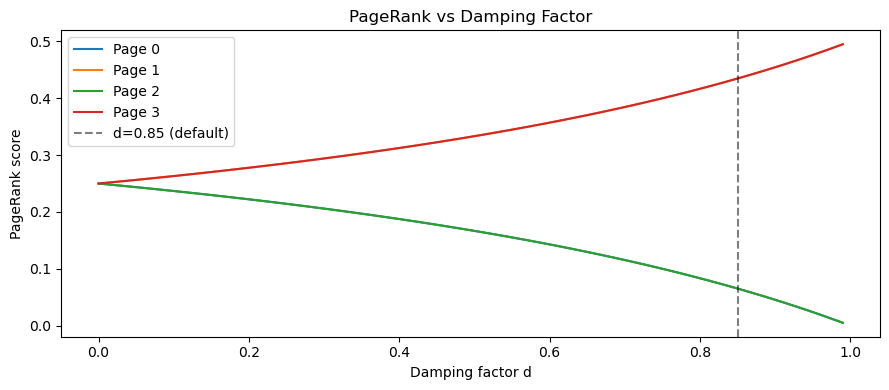

In [6]:
def prob4():
    """Plot PageRank scores vs damping factor d."""
    d_values = np.linspace(0, 0.99, 50)
    all_ranks = [prob3(A, d=d) for d in d_values]
    all_ranks = np.array(all_ranks)  # shape (50, 4)
    
    plt.figure(figsize=(9, 4))
    for i in range(A.shape[0]):
        plt.plot(d_values, all_ranks[:, i], label=f'Page {i}')
    plt.axvline(0.85, color='k', linestyle='--', alpha=0.5, label='d=0.85 (default)')
    plt.xlabel('Damping factor d')
    plt.ylabel('PageRank score')
    plt.title('PageRank vs Damping Factor')
    plt.legend()
    plt.tight_layout()
    
    plt.show()

prob4()

## Problem 5: Ranking a Larger Graph

Apply PageRank to a random directed graph and visualize with node sizes proportional to rank.

Converged in 23 iterations


/tmp/ipykernel_16903/3527601593.py:17: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


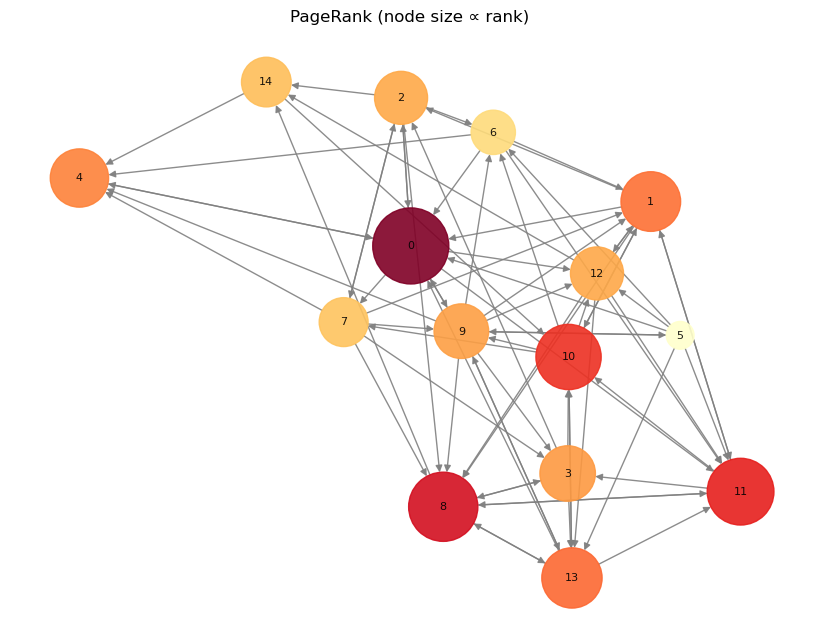

Top 5 pages by rank:
  #1: Page 0 (score 0.1177)
  #2: Page 8 (score 0.0974)
  #3: Page 11 (score 0.0906)
  #4: Page 10 (score 0.0867)
  #5: Page 13 (score 0.0740)


In [7]:
def prob5(n=15, seed=7):
    """PageRank visualization on a random graph."""
    rng = np.random.default_rng(seed)
    G = nx.erdos_renyi_graph(n, 0.3, directed=True, seed=seed)
    
    A_big = nx.to_numpy_array(G).T   # A[i,j]=1 if j→i
    ranks = prob3(A_big)
    
    pos = nx.spring_layout(G, seed=seed)
    sizes = 3000 * ranks / ranks.max()
    
    plt.figure(figsize=(8, 6))
    nx.draw(G, pos, node_size=sizes, node_color=ranks,
            cmap='YlOrRd', with_labels=True, arrows=True,
            font_size=8, edge_color='gray', alpha=0.9)
    plt.title('PageRank (node size ∝ rank)')
    plt.tight_layout()
    
    plt.show()
    
    print("Top 5 pages by rank:")
    top5 = np.argsort(ranks)[::-1][:5]
    for i, page in enumerate(top5):
        print(f"  #{i+1}: Page {page} (score {ranks[page]:.4f})")

prob5()